<a href="https://colab.research.google.com/github/benasphy/KNN/blob/main/KNN_implementation_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 100.00%
Prediction for [5.1 3.5]: Class 0 (setosa)


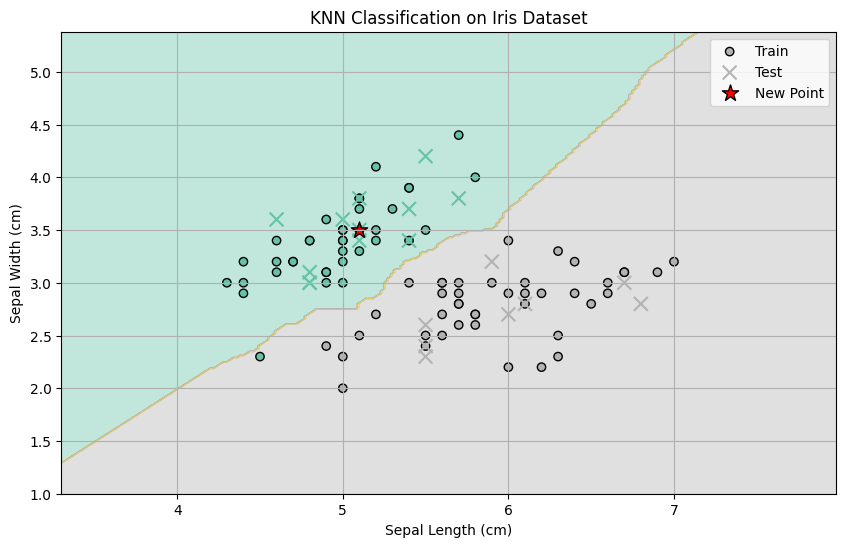

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from collections import Counter

# 1. Load Dataset (Use only class 0 and 1 for simplicity)
iris = datasets.load_iris()
X = iris.data[:, :2]  # Use only sepal length and width
y = iris.target

# Filter only Setosa (0) and Versicolor (1)
X = X[y != 2]
y = y[y != 2]
target_names = iris.target_names[:2]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. KNN Implementation
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]

    def accuracy(self, y_true, y_pred):
        return np.mean(y_true == y_pred)

# 4. Train Model
knn = KNN(k=5)
knn.fit(X_train, y_train)

# 5. Predict Test Set & Accuracy
y_pred = knn.predict(X_test)
accuracy = knn.accuracy(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# 6. Predict Example Input
new_point = np.array([[5.1, 3.5]])  # You can change this to test others
predicted_class = knn.predict(new_point)[0]
print(f"Prediction for {new_point[0]}: Class {predicted_class} ({target_names[predicted_class]})")

# 7. Visualize Decision Boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='Set2')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', label='Train', cmap='Set2')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', s=100, label='Test', cmap='Set2')
plt.scatter(new_point[0][0], new_point[0][1], c='red', edgecolor='black', s=150, label='New Point', marker='*')
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("KNN Classification on Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()
